In [8]:
from idlelib.debugger_r import GUIAdapter
from itertools import groupby

import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from matplotlib.pyplot import title
from scipy.sparse import coo

In [20]:
df = pd.read_csv("Spotify.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [12]:
df.shape

(114000, 21)

In [14]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [17]:
df = df.dropna()

In [18]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='str')

In [29]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


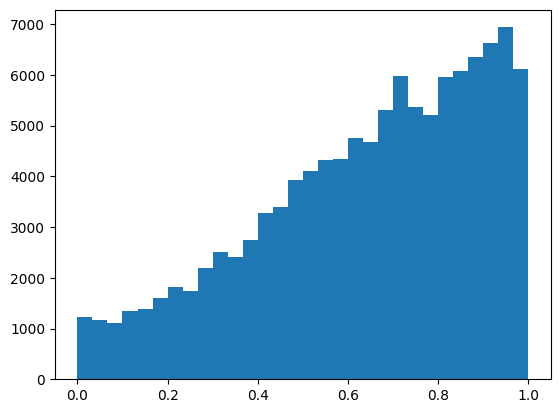

In [31]:
plt.hist(df["energy"], bins=30)
plt.show()

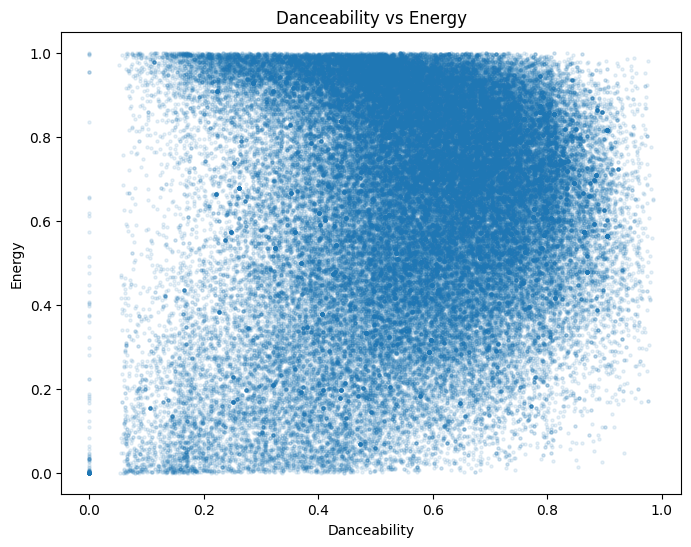

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(df['danceability'], df['energy'], alpha=0.1, s=5)

plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.title("Danceability vs Energy")
plt.show()

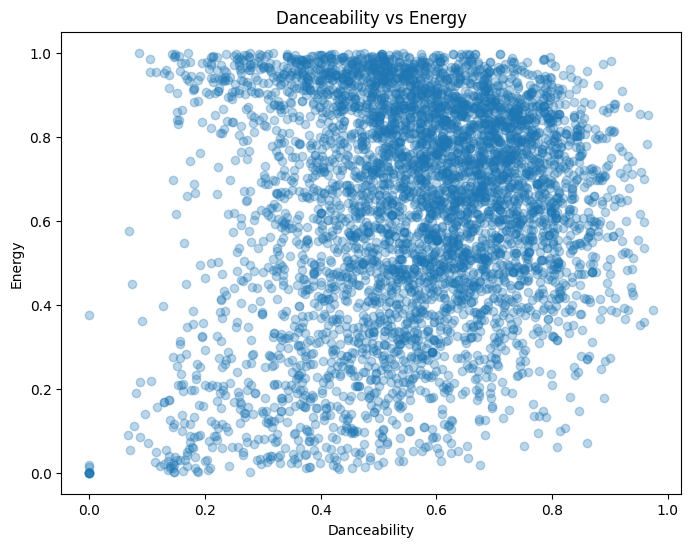

In [35]:
sample_df = df.sample(5000)
plt.figure(figsize=(8,6))

plt.scatter(sample_df['danceability'], sample_df['energy'], alpha=0.3)

plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.title("Danceability vs Energy")
plt.show()

In [36]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='str')

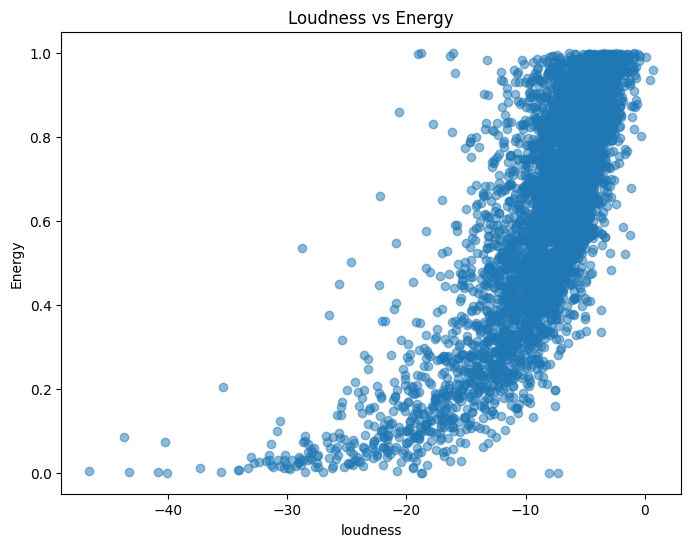

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(sample_df['loudness'], sample_df['energy'], alpha=0.5)

plt.xlabel("loudness")
plt.ylabel("Energy")
plt.title("Loudness vs Energy")
plt.show()

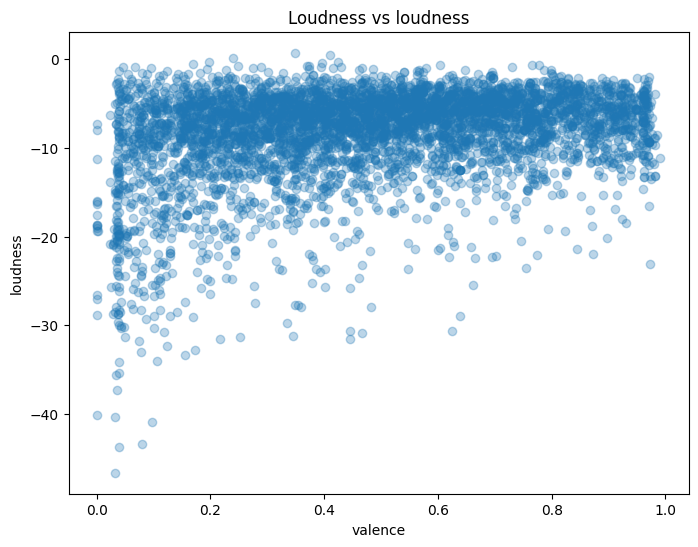

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(sample_df['valence'], sample_df['loudness'], alpha=0.3)

plt.xlabel("valence")
plt.ylabel("loudness")
plt.title("Loudness vs loudness")
plt.show()

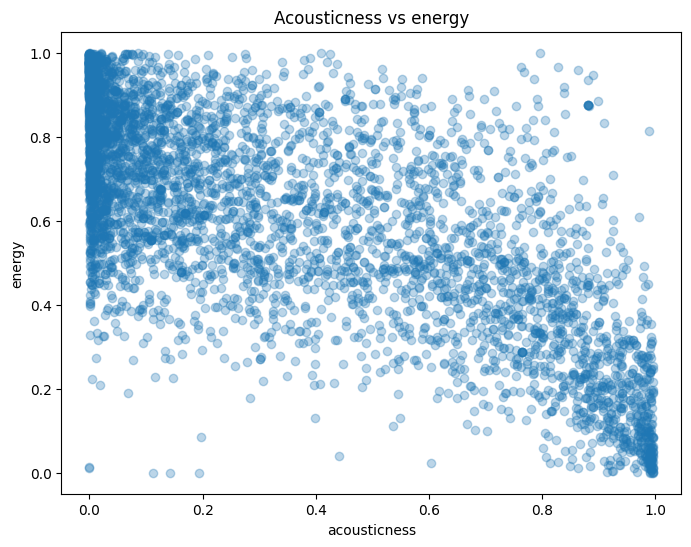

In [41]:
plt.figure(figsize=(8, 6))

plt.scatter(sample_df['acousticness'], sample_df['energy'], alpha=0.3)

plt.xlabel("acousticness")
plt.ylabel("energy")
plt.title("Acousticness vs energy")
plt.show()

In [42]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]
corr = df[features].corr()
print(corr)

                  danceability    energy  loudness  speechiness  acousticness  \
danceability          1.000000  0.134325  0.259077     0.108626     -0.171533   
energy                0.134325  1.000000  0.761690     0.142509     -0.733906   
loudness              0.259077  0.761690  1.000000     0.060826     -0.589803   
speechiness           0.108626  0.142509  0.060826     1.000000     -0.002186   
acousticness         -0.171533 -0.733906 -0.589803    -0.002186      1.000000   
instrumentalness     -0.185606 -0.181879 -0.433477    -0.089616      0.104027   
liveness             -0.131617  0.184796  0.076899     0.205219     -0.020700   
valence               0.477341  0.258934  0.279848     0.036635     -0.107070   
tempo                -0.050450  0.247851  0.212446     0.017273     -0.208224   

                  instrumentalness  liveness   valence     tempo  
danceability             -0.185606 -0.131617  0.477341 -0.050450  
energy                   -0.181879  0.184796  0.258934 

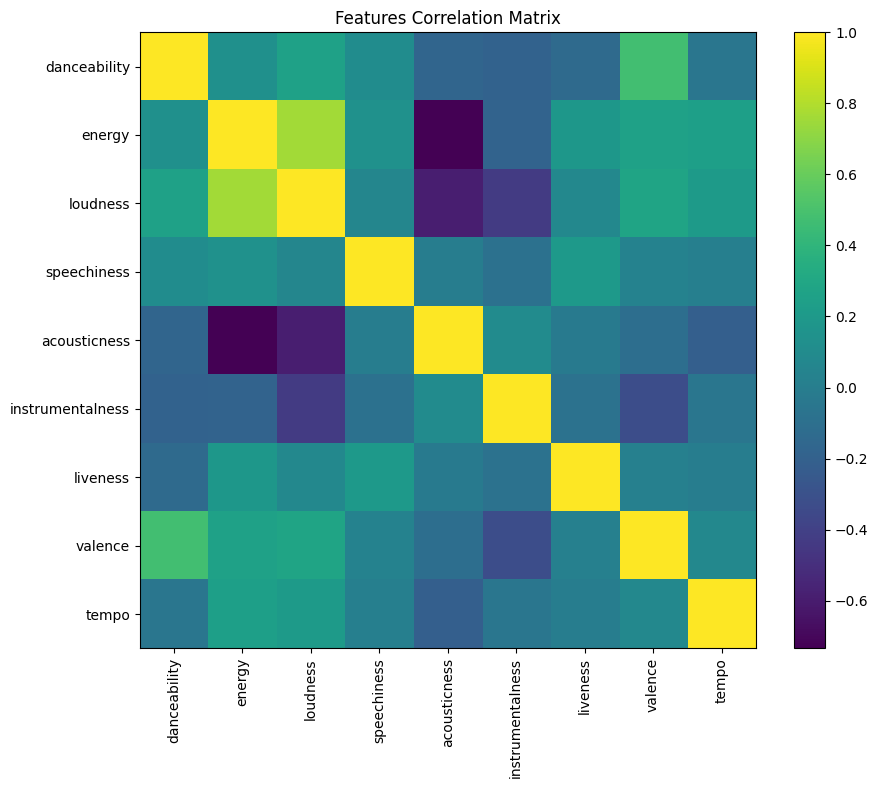

In [45]:
plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)

plt.title("Features Correlation Matrix")
plt.show()

In [46]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]
x = df[features]

In [47]:
x = x.dropna()

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [49]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)

gmm.fit(x_scaled)

,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [51]:
labels = gmm.predict(x_scaled)
x["Cluster"] = labels

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

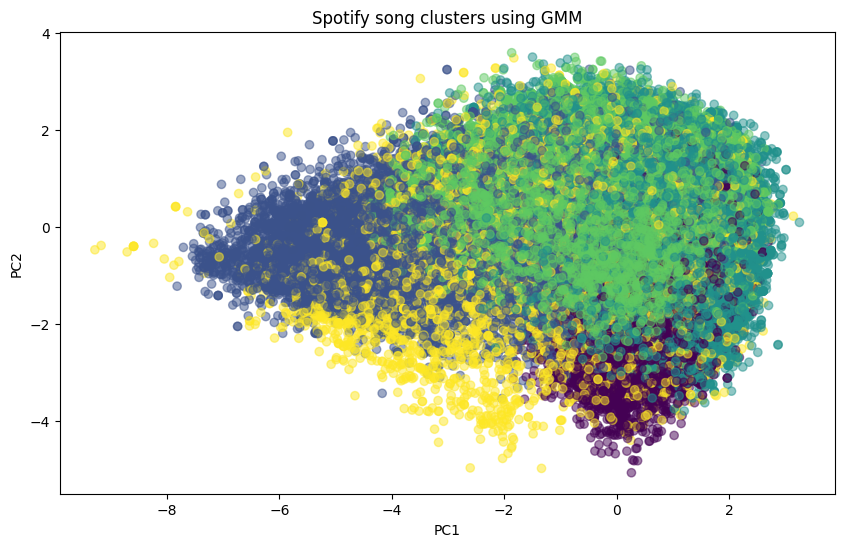

In [52]:
plt.figure(figsize=(10,6))

plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels, alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spotify song clusters using GMM")
plt.show()

In [55]:
print(x.groupby("Cluster").mean())

         danceability    energy   loudness  speechiness  acousticness  \
Cluster                                                                 
0            0.507104  0.869857  -6.078549     0.076954      0.002189   
1            0.517410  0.423061 -13.728948     0.042732      0.535974   
2            0.622816  0.715013  -6.600584     0.186469      0.275721   
3            0.576057  0.618301  -7.358065     0.043651      0.341681   
4            0.556495  0.608292 -10.398503     0.108791      0.363463   

         instrumentalness  liveness   valence       tempo  
Cluster                                                    
0                0.379483  0.213300  0.363166  131.057545  
1                0.493268  0.109407  0.347025  115.077776  
2                0.000064  0.348410  0.561537  124.309669  
3                0.000111  0.158709  0.520375  121.330471  
4                0.369787  0.314741  0.419702  119.782959  


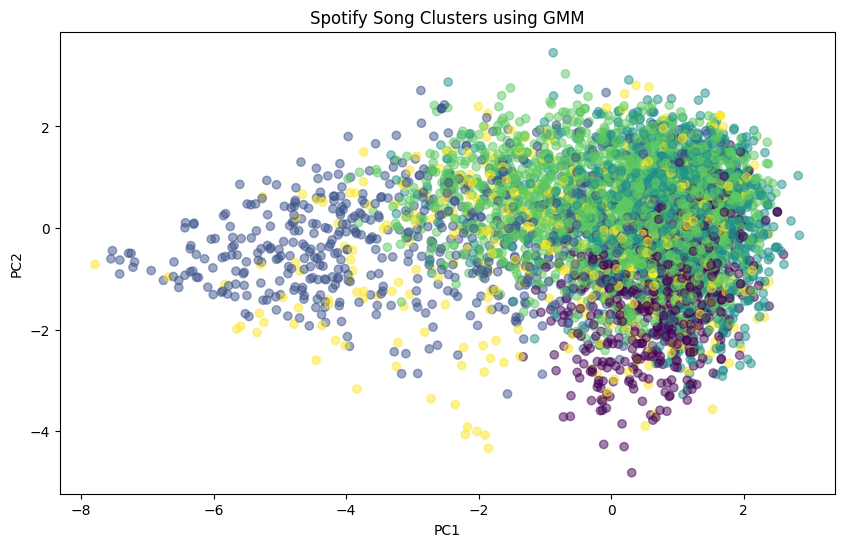

In [56]:
sample_indices = np.random.choice(
    len(x_pca),
    5000,
    replace=False
)

plt.figure(figsize=(10,6))

plt.scatter(
    x_pca[sample_indices,0],
    x_pca[sample_indices,1],
    c=labels[sample_indices],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Spotify Song Clusters using GMM")

plt.show()

In [57]:
bic_score = []

for i in range(1,11):
    gmm = GaussianMixture(n_components=i, random_state=42)

    gmm.fit(x_scaled)
    bic_score.append(gmm.bic(x_scaled))

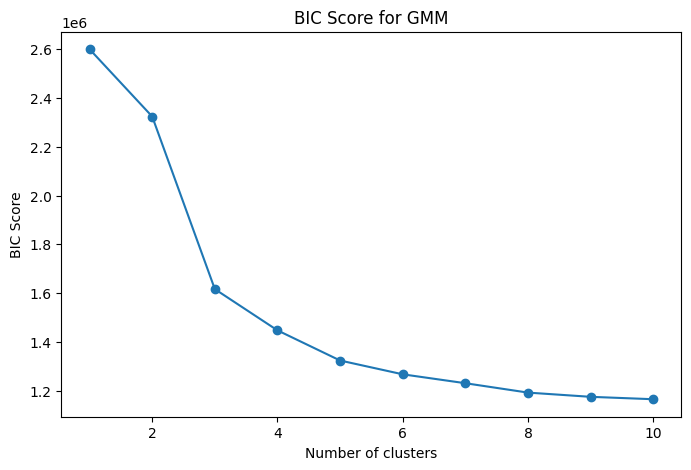

In [58]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), bic_score, marker="o")

plt.xlabel("Number of clusters")
plt.ylabel("BIC Score")

plt.title("BIC Score for GMM")
plt.show()

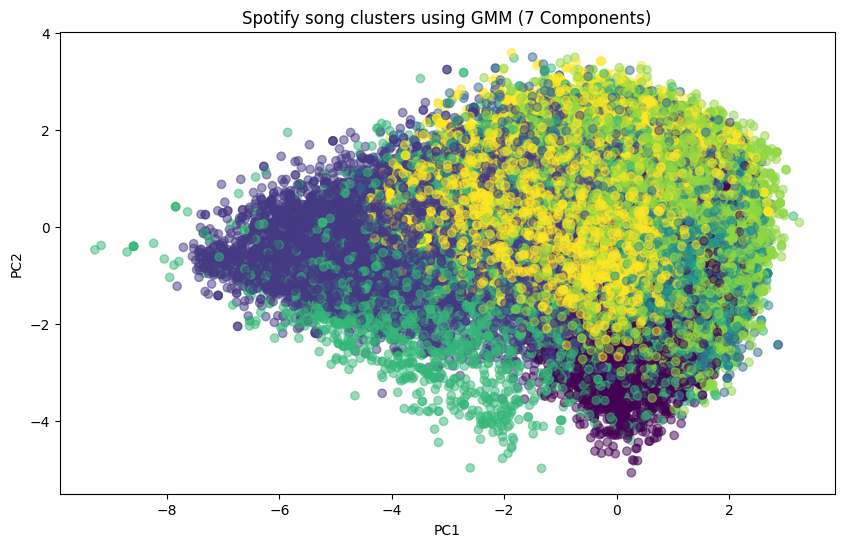

In [63]:
gmm = GaussianMixture(n_components=7, random_state=42)
gmm.fit(x_scaled)
labels = gmm.predict(x_scaled)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(10,6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels, alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spotify song clusters using GMM (7 Components)")
plt.show()

In [64]:
x["Cluster"] = labels

print(x.groupby("Cluster").mean())

         danceability    energy   loudness  speechiness  acousticness  \
Cluster                                                                 
0            0.515089  0.863214  -6.275257     0.074588      0.001788   
1            0.509987  0.412522 -14.019472     0.042670      0.550455   
2            0.614219  0.658830  -8.866976     0.251401      0.378567   
3            0.509798  0.873534  -4.777358     0.068510      0.006184   
4            0.537679  0.588742 -11.126042     0.106611      0.375103   
5            0.634215  0.695500  -6.521712     0.131157      0.290957   
6            0.576874  0.553068  -8.035598     0.040066      0.419561   

         instrumentalness  liveness   valence       tempo  
Cluster                                                    
0                0.431547  0.214723  0.362976  130.984239  
1                0.530316  0.108785  0.329479  114.594057  
2                0.003458  0.317017  0.528721  118.840545  
3                0.000223  0.209682  0.489